In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# 1. Path to your zip in Drive
zip_path = '/content/drive/MyDrive/AI Datasets/human_emotions_data.zip'
extract_to = '/content/emotions_data'

# 2. Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# 3. Locate the actual data directory
# Sometimes zipping adds a "human_emotions_data" folder inside the zip
data_dir = extract_to
if 'human_emotions_data' in os.listdir(extract_to):
    data_dir = os.path.join(extract_to, 'human_emotions_data')

print(f"Subfolders found: {os.listdir(data_dir)}")

Subfolders found: ['Suprise', 'Angry', 'Sad', 'Fear', 'Happy']


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load dataset and Shuffle to prevent the 1.0 accuracy flat-line
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(32, 32),
    batch_size=None, # None lets us iterate image by image for the array
    shuffle=True,    # CRITICAL: prevents the model from seeing one class at a time
    seed=123
)

class_names = full_ds.class_names
images, labels = [], []

# Convert to NumPy Arrays
for img, label in full_ds:
    images.append(img.numpy())
    labels.append(label.numpy())

images = np.array(images)
labels = np.array(labels).reshape(-1, 1)

# Split into Train/Test (80/20)
split = int(0.8 * len(images))
train_images, test_images = images[:split], images[split:]
train_labels, test_labels = labels[:split], labels[split:]

# NORMALIZE pixel values to be between 0 and 1
# Ensure this is only done once to avoid black images
train_images, test_images = train_images / 255.0, test_images / 255.0

Found 59099 files belonging to 5 classes.


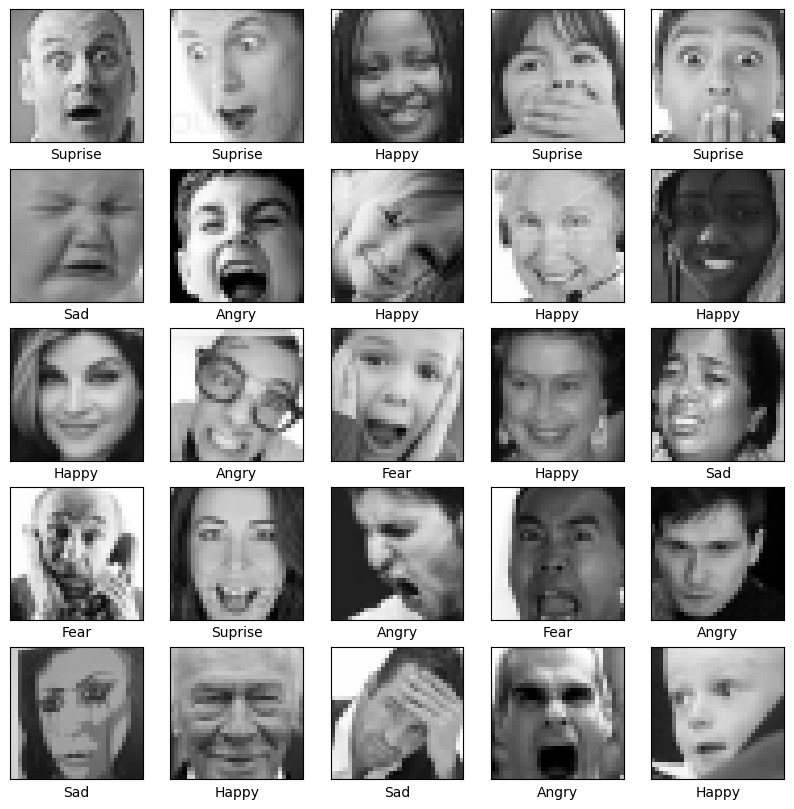

Epoch 1/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4033 - loss: 1.4146 - val_accuracy: 0.5318 - val_loss: 1.1497
Epoch 2/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5528 - loss: 1.1007 - val_accuracy: 0.5836 - val_loss: 1.0347
Epoch 3/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6148 - loss: 0.9723 - val_accuracy: 0.6121 - val_loss: 0.9742
Epoch 4/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6436 - loss: 0.8897 - val_accuracy: 0.6255 - val_loss: 0.9533
Epoch 5/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6858 - loss: 0.8091 - val_accuracy: 0.6658 - val_loss: 0.8744
Epoch 6/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7243 - loss: 0.7176 - val_accuracy: 0.6806 - val_loss: 0.8332
Epoch 7/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7547 - loss: 0.6436 - val_accuracy: 0.6897 - val_loss: 0.8168
Epoch 8/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7829 - loss: 0.5722 -

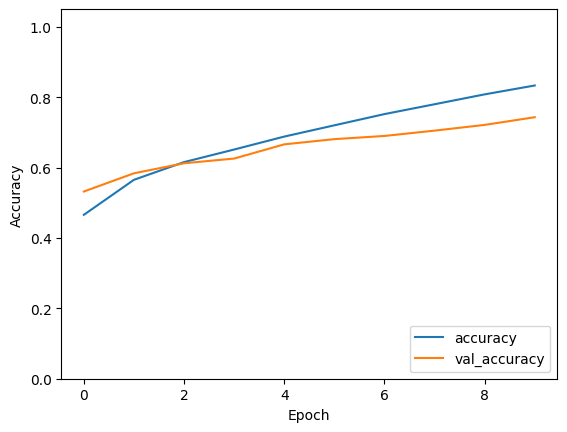

370/370 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7454 - loss: 0.7502

Final Test accuracy: 0.742893397808075


In [ ]:
# 1. Display first 25 images to verify they aren't black
plt.figure(figsize=(10,10))
for i in range(min(25, len(train_images))):
    plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

# 2. Build the Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names)) # Automatically matches 5 classes
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Fit the Model
CNN = model.fit(train_images, train_labels, epochs=10,
                validation_data=(test_images, test_labels))

# 4. Plot with fixed limits
plt.plot(CNN.history['accuracy'], label='accuracy')
plt.plot(CNN.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05]) # Set slightly above 1 so the line is visible
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels)
print('\nFinal Test accuracy:', test_acc)

Saving 15.png to 15 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


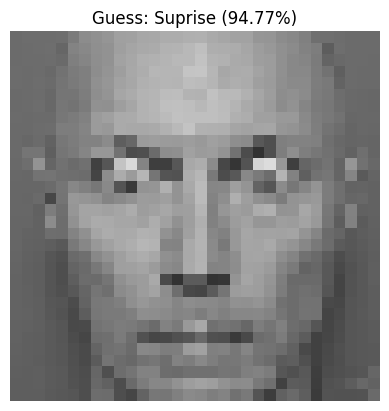

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Upload the file
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. Load the image and resize it to 32x32 to match the model's "brain"
  path = '/content/' + fn
  img = image.load_img(path, target_size=(32, 32))

  # 3. Convert image to numbers and normalize (0 to 1)
  img_array = image.img_to_array(img)
  img_array = img_array / 255.0  # Same math we did for the training set
  img_array = np.expand_dims(img_array, axis=0) # Make it a "batch" of 1

  # 4. Ask the model to guess
  predictions = model.predict(img_array)
  score = tf.nn.softmax(predictions[0]) # Convert the guess into a percentage/probability

  # 5. Show the result
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Guess: {class_names[np.argmax(score)]} ({100 * np.max(score):.2f}%)")
  plt.show()

In [ ]:
# Save the model to your Google Drive
model_save_path = '/content/drive/MyDrive/AI Datasets/emotion_model.h5'
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/AI Datasets/emotion_model.h5


In [ ]:
import numpy as np

# Save the history dictionary
history_path = '/content/drive/MyDrive/AI Datasets/training_history.npy'
np.save(history_path, CNN.history)
print(f"History saved to: {history_path}")

History saved to: /content/drive/MyDrive/AI Datasets/training_history.npy


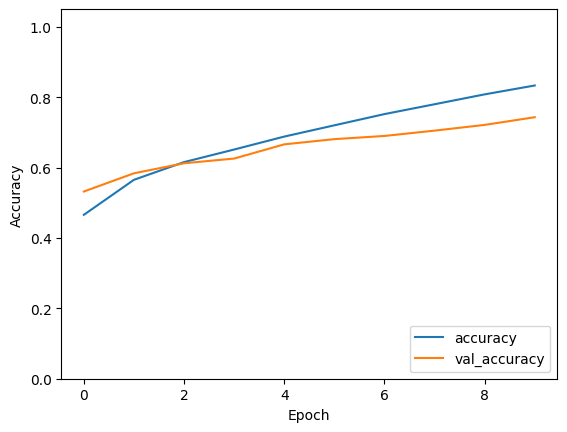

Model and Graph reloaded successfully!


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the model
model = tf.keras.models.load_model('/content/drive/MyDrive/AI Datasets/emotion_model.h5')

# 2. Load the history
history = np.load('/content/drive/MyDrive/AI Datasets/training_history.npy', allow_pickle='TRUE').item()

# 3. Re-plot the graph instantly
plt.plot(history['accuracy'], label='accuracy')
plt.plot(history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])
plt.legend(loc='lower right')
plt.show()

print("Model and Graph reloaded successfully!")